In [12]:
import torch
from torchvision.transforms.v2 import RandomHorizontalFlip as rhflip, RandomVerticalFlip as rvflip
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
# global_path = "/Users/edabier/Documents/Thèse/Thèse_Télécom"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [13]:
dataset = "apex"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
Y_init_n = utils.standardise(Y_init)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

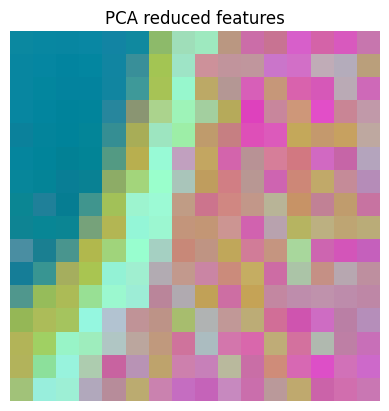

In [14]:
fm_name = "Panopticon"
fm, _, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)
Y_init_f, A_init_f = rsfm.reshape_Y(fm_name, Y_init, new_H, A_init)
_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)
plots.plot_pca_features(features)

In [15]:
unfold = nn.Unfold(kernel_size=new_H//2, stride=new_H//2)

Y_patches = unfold(Y_init_f).permute(0,2,1)
Y_patches = utils.oneD_to_2d(Y_patches.reshape(Y_patches.shape[1], B, -1))

feat_unfold = nn.Unfold(kernel_size=alpha//2, stride=alpha//2)
features_patches = feat_unfold(utils.oneD_to_2d(features)).T
features_patches = utils.oneD_to_2d(features_patches.reshape(features_patches.shape[0], D, -1))

In [ ]:
from UpsampleAnythingPytorch.src.upsample_anything import UPA

feat_up = torch.zeros(1, D, new_H, new_H)

for i in range(features_patches.shape[0]):
    f_up = UPA(Y_patches[i].cpu(), features_patches[i].unsqueeze(0))
    feat_up[:,:,i//2*new_H//2:i//2*new_H//2+new_H//2, i%2*new_H//2:i%2*new_H//2+new_H//2] = f_up
plots.plot_pca_features(feat_up, title="UPA features")

/home/ids/edabier/HSU/UpsampleAnythingPytorch/src/upsample_anything.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/home/ids/edabier/HSU/UpsampleAnythingPytorch/src/upsample_anything.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
/home/ids/edabier/HSU/UpsampleAnythingPytorch/src/upsample_anything.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = torch.cuda.amp.autocast(enabled=use_autocast, dtype=torch.float16)
/home/ids/edabier/HSU/UpsampleAnythingPytorch/src/upsample_anything.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

In [85]:
# from UpsampleAnythingPytorch.src.upsample_anything import UPA

# # n = nearest_multiple(H, alpha)
# # Y = F.interpolate(Y_init, size=(n*alpha, n*alpha))
# # A = F.interpolate(A_init, size=(n*alpha, n*alpha))

# features_up = UPA(Y_init_f[0].cpu(), utils.oneD_to_2d(features).unsqueeze(0))
# plots.plot_pca_features(features_up)
# feat_up = features_up.clone()

### Unmixing from upsampled features

In [12]:
class UnmixingFromUpFeat(nn.Module):
    """
    Unmix from NAF upsampled features + linear regulation
    """
    def __init__(self, D, B, c, H=224):
        """
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi

        """
        super(UnmixingFromUpFeat, self).__init__()
        self.D = D
        self.B = B
        self.c = c
        self.H = H

        self.regul = nn.Linear(self.D, self.D)
        self.abundance_estimator = nn.Sequential(
            nn.Conv2d(D, c, kernel_size=1, bias=False),
            nn.LeakyReLU(0.02),
            nn.BatchNorm2d(c),
            nn.Dropout(0.2)
        )

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_tv_a=0):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        # TV on abundances (sum of difference between consecutive horizontal pixels + vertical pixels)
        loss_tv_a = W_tv_a * tv(A_hat)

        loss = loss_sad + loss_ab + loss_tv_e + loss_tv_a

        return loss

    def get_abundances(self, features):
        features = self.regul(features.permute(0,2,3,1)).permute(0,3,1,2)
        # features = (features - features.mean())/ (1e-8 + features.std())
        A_hat = self.abundance_estimator(features)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features):
        A_hat = self.get_abundances(features)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

Training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.146, NMSE = 0.497
Training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.154, NMSE = 0.483
Training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.177, NMSE = 0.377
Training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.120, NMSE = 0.481
Training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.120, NMSE = 0.450
Training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.136, NMSE = 0.464
Training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.142, NMSE = 0.456

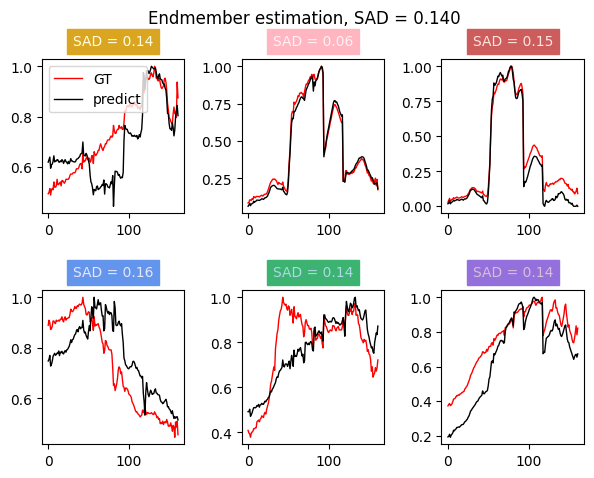

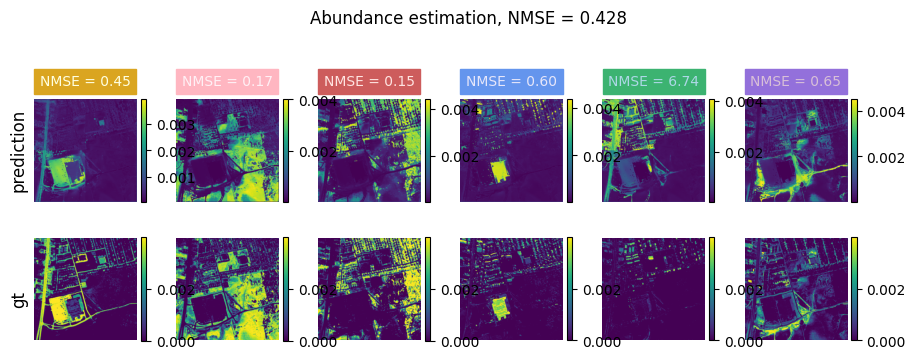

In [13]:
linear = False
n_train = 15
E_hats, A_hats = torch.zeros(n_train, B, c), torch.zeros(n_train, c, new_H, new_H)
sads, mses = [], []

for i in range(n_train): 
    
    print(f"Training {i+1}/{n_train}")

    if linear:
        model = UnmixingFromUpFeat(D, B, c, new_H)
    else:
        model = unmx.UnmixingFromUpFeat(D, B, c, new_H)

    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002

    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):
    
        optimizer.zero_grad()

        E_hat, A_hat, Y_hat = model(feat_up)

        loss = model.loss(Y_init_f, Y_hat, A_hat, E_hat)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        E_hat, A_hat, Y_hat = model(feat_up)

        if not E_hat.isnan().any().item() and not A_hat.isnan().any().item():
            sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_f, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
            print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
            sads.append(sad)
            mses.append(mse)
        else:
            print(E_hat.isnan().any(), A_hat.isnan().any())

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

valid_mask_E = ~torch.isnan(E_hats).any(dim=(1,2))
valid_E_hats = E_hats[valid_mask_E]
valid_mask_A = ~torch.isnan(A_hats).any(dim=(1,2,3))
valid_A_hats = A_hats[valid_mask_A]

for i in range(n_train):
    if E_hats[i].isnan().any():
        print(E_hats[i].isnan().any(), i)

if valid_A_hats.shape[0] > 0:
    A_hat_m = torch.mean(valid_A_hats, dim=0)
if valid_E_hats.shape[0] > 0:
    E_hat_m = torch.mean(valid_E_hats, dim=0)
    sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_f, E_init, normalize_E=True, normalize_A=True, return_results=True)
    print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")
else:
    sad, mse = 0, 0
    print("No valid prediction for E_hat, all nans")
print(sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6)

### Features fusion from upsampled feat

In [17]:
class FeaturesFusionUpsampler(nn.Module):
    def __init__(self, C, B, alpha, H):
        super().__init__()
        self.C = C
        self.B = B
        self.alpha = alpha
        self.H = H

        self.upsample = nn.Conv2d(C, C, kernel_size=3, padding=1, groups=C)

        self.extract_hr = nn.Conv2d(B, C, kernel_size=1)

        self.fuse = nn.Sequential(
            nn.Conv2d(2 * C, C, kernel_size=3, padding=1, groups=C),
            nn.BatchNorm2d(C),
            nn.LeakyReLU(0.01),
        )

    def forward(self, x_lr, x_hr):
        # x_lr: (batch, C, alpha, alpha)
        # x_hr: (batch, B, H, H)

        x_upsampled = self.upsample(x_lr)
        x_hr_feat = self.extract_hr(x_hr)
        x_fused = torch.cat([x_upsampled, x_hr_feat], dim=1)
        x_fused = self.fuse(x_fused)

        return x_fused
    
class UnmixingFromFeatures(nn.Module):
    def __init__(self, D, B, c, H=224, alpha=None, n_features=1):
        """
        Upsamples low res features then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi
            alpha (int): The size of the features
            n_features (int): The size of the list of features in the case of several extracted features

        """
        super(UnmixingFromFeatures, self).__init__()
        self.D = D
        self.alpha = alpha
        self.B = B
        self.c = c
        self.H = H
        self.n_features = n_features

        # Upsampling features
        self.upsample = FeaturesFusionUpsampler(self.n_features*D, B, alpha, H)

        # Upsampled features to abundances
        self.abundance_estimator = nn.Sequential(
            nn.Conv2d(self.n_features*D, c, kernel_size=1, bias=False),
            nn.LeakyReLU(0.02),
            nn.BatchNorm2d(c),
            nn.Dropout(0.2)
        )

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, features_hr=None, features_lr=None, channel_selector=None, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_tv_a=0, W_mse=0.09, W_e=0, W_feat=0, W_tv_feat=0, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Feature regularisation"""

        if features_hr != None:
            l1 = nn.L1Loss()
            downsample = nn.AdaptiveAvgPool2d(features_lr[0].shape)
            features_down = downsample(features_hr)

            loss_features = W_feat * l1(utils.normalize(features_down), utils.normalize(features_lr))
        
        else:
            loss_features = 0

        loss = loss_sad + loss_ab + loss_mse + loss_features

        if channel_selector != None:
            loss += torch.linalg.norm(channel_selector, dim=0, ord=1)#/ len(channel_selector)

        if return_losses:
            return loss, loss_sad, loss_ab, loss_mse
        else:
            return loss

    def get_abundances(self, features, Y):

        features_up = self.upsample(features, Y)
        
        features_up = (features_up - features_up.mean())/ (1e-8 + features_up.std())
        A_hat = self.abundance_estimator(features_up)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features, Y):
        A_hat = self.get_abundances(features, Y)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

In [ ]:
features_map = feat_up.clone()
n_xp = 15
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):
    
        optimizer.zero_grad()
        
        E_hat, A_hat, Y_hat = model(features_map, Y_init_f)

        loss = model.loss(Y_init_f, Y_hat, A_hat, E_hat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        E_hat, A_hat, _ = model(features_map, Y_init_f)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_f, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_f, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')} NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")